In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

# Adds the root_dir (parent of notebooks/) to sys.path
parent_dir = str(Path().resolve().parent)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [18]:
# all libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from datetime import datetime
import joblib
import lightgbm as lgb 
plt.style.use('seaborn-v0_8-darkgrid')

from src.metrics import wrmsse, calculate_mape, calculate_wape, bias
from src.features import GetFeatures , get_avg_sales, get_price_features, get_trend_features
from src.utils import get_items_top, get_items_with_full_history
from src.pipeline import recursive_forecast_batch
from train_and_eval import train_models

import warnings

In [4]:
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR/"data"/"processed"

parent_dir

'/media/ashfaque/datas/ML-projects/retail-forecast-system'

In [5]:
models_dir = BASE_DIR/'models' 
model_point = joblib.load(models_dir/"lgb_ca1_2yr_point.pkl")
model_q10 = joblib.load(models_dir/'lgb_ca1_2yr_q10.pkl')
model_q90 = joblib.load(models_dir/'lgb_ca1_2yr_q90.pkl')


items_373 = pd.read_pickle(models_dir/"items_full_history_ca1.pkl")['items']

# future_data = pd.read_parquet(DATA_DIR/'sales_future_ca_1.parquet')
known_data = pd.read_parquet(DATA_DIR/'sales_known_ca_1.parquet')


In [6]:
training_data = known_data.copy()

training_data['sell_price'] = known_data['sell_price'].astype(np.float32)
training_data.describe()

,sales,date,wm_yr_wk,wday,month,year,snap_CA,snap_TX,snap_WI,sell_price,day_of_week,day_of_month,week_of_year
count,4.367553e+06,4367553,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06
mean,1.651214e+00,2013-11-05 22:37:51.253858816,1.135349e+04,3.995814e+00,6.694819e+00,2.013334e+03,3.292271e-01,3.282598e-01,3.282994e-01,4.404971e+00,3.000000e+00,1.572730e+01,2.740658e+01
min,0.000000e+00,2011-01-29 00:00:00,1.110100e+04,1.000000e+00,1.000000e+00,2.011000e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.000214e-02,0.000000e+00,1.000000e+00,1.000000e+00
25%,0.000000e+00,2012-09-28 00:00:00,1.123500e+04,2.000000e+00,4.000000e+00,2.012000e+03,0.000000e+00,0.000000e+00,0.000000e+00,2.179688e+00,1.000000e+00,8.000000e+00,1.500000e+01
50%,0.000000e+00,2013-12-25 00:00:00,1.134800e+04,4.000000e+00,7.000000e+00,2.013000e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.470703e+00,3.000000e+00,1.600000e+01,2.800000e+01
75%,2.000000e+00,2015-01-11 00:00:00,1.145000e+04,6.000000e+00,1.000000e+01,2.015000e+03,1.000000e+00,1.000000e+00,1.000000e+00,5.769531e+00,5.000000e+00,2.300000e+01,4.000000e+01
max,6.480000e+02,2016-01-05 00:00:00,1.154900e+04,7.000000e+00,1.200000e+01,2.016000e+03,1.000000e+00,1.000000e+00,1.000000e+00,3.098438e+01,6.000000e+00,3.100000e+01,5.300000e+01
std,4.531837e+00,NaN,1.353110e+02,1.999647e+00,3.414441e+00,1.358328e+00,4.699326e-01,4.695800e-01,4.695945e-01,3.382993e+00,2.001744e+00,8.821408e+00,1.491540e+01


In [7]:
# convert the event cols into categorical
# List of all categorical columns
# 1. Fill missing event values

for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]:
    if col in training_data.columns:
        training_data[col] = (
            training_data[col].astype(str).replace("nan", "None")
        )
        training_data[col] = training_data[col].astype("category")


In [8]:
# unique items
training_data['item_id'].nunique()

3047

### Features into buckets:

We will generate new features that could help us in predict the sales better, which inherently belongs to certain buckets/groups, so we can identify which of these features actually impacted our model

* Currently what we have is basic features that come wth data -- base_set
* lag features --- all lag features - LAG_SET
* rolling window buckets: all rolling features -  ROLLING_SET
* price dynamics bucket: currently we only use sale price, we will add price dynamics, relative price difference (in subcategory), over the week (promotional effect)- PRICE_SET
* Heirarchical aggregate buckets: to capture group level averages - AGG_SET


In [62]:
# in base set we only pick snap_CA, as the data contains only 'CA' and store 'CA_1', which make store_id, and state_id redundant
BASE_SET = [ 'item_id', 'dept_id', 'cat_id', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'sell_price', 'day_of_week',
       'day_of_month', 'week_of_year']

LAG_SET  = ['lag_1','lag_2','lag_3','lag_7','lag_14','lag_21','lag_28','lag_60','lag_90']

ROLLING_SET = ['rolling_mean_3','rolling_mean_7','rolling_mean_14','rolling_mean_21','rolling_mean_28','rolling_mean_60','rolling_mean_90',
               'rolling_lag_7_win_7','rolling_lag_7_win_28','rolling_lag_28_win_7','rolling_lag_28_win_28',
                'rolling_max_2','rolling_max_3','rolling_max_7', 'rolling_max_14','rolling_max_21','rolling_max_28','rolling_max_60','rolling_max_90']

PRICE_SET = ['price_ratio_mean','is_discounted','delta_price_rltv_dept','historical_std','historical_mean']

AGG_SET  = ['item_sold_avg','dept_sold_avg','cat_sold_avg']

TREND_SET = ['selling_trend','demand_vs_historical_mean'] # rolling_mean_7/rolling_mean_28, rolling_mean_7/historical_mean


feat_set_1 = BASE_SET
feat_set_2 = BASE_SET + LAG_SET 
feat_set_3 = BASE_SET + LAG_SET + ROLLING_SET 
feat_set_4 = BASE_SET + LAG_SET + ROLLING_SET + PRICE_SET 
feat_set_5 = BASE_SET + LAG_SET + ROLLING_SET + PRICE_SET + AGG_SET
feat_set_6 = feat_set_5 + TREND_SET 

feature_sets = [feat_set_1,feat_set_2,feat_set_3,feat_set_4,feat_set_5,feat_set_6]
name_sets = ['BASE_SET','LAG_SET','ROLLING_SET','PRICE_SET','AGG_AVG_SET','TREND_SET']

### Recursive forecast

* model: lightGBM
* forecast type : direct (with leakage)
* forecasting horizon : 28 days
* training period : 700 days 
* metrics: WRMSSE, WAPE, BIAS, FVA 

In [14]:
# initilize the GetFeatures class for lag and rolling features
get_features = GetFeatures()

In [11]:
# we limit our training days to recent two years of data
cutoff_date = training_data['date'].max()-pd.Timedelta(days=730)
train_recursive = training_data[training_data['date']>=cutoff_date].copy()

In [12]:
min_days_threshold = 90

# Create a row-level mask based on group counts
valid_mask = ( train_recursive.groupby('item_id',observed=True)['date'].transform('count')
    >= min_days_threshold)
# Filter the original dataframe
train_recursive = train_recursive[valid_mask]

train_recursive['item_id'].nunique()

3043

In [ ]:
# calculate all feature set on full 2 year data, later delete the features that need to be calculated in recursive
# from test set

# price feaetures : we already know the price for the future
train_recursive = get_price_features(train_recursive)
# lag features, remember: we have to delete the cols that need to be in recursive loop from test dataset
#this col from test after this
train_recursive = get_features.add_lags(train_recursive,lags=[1,2,3,7,14,21,28,60,90])
# rolling features 
train_recursive = get_features.add_rolling_max(train_recursive,source_col='lag_1',windows=[2,3,7,14,21,28,60,90])
train_recursive = get_features.add_rolling_mean(train_recursive,source_col='lag_1',windows=[3,7,14,21,28,60,90])
train_recursive = get_features.add_rolling_on_lag(train_recursive,lags=[7,28],windows=[7,28])
# get trend features
train_recursive = get_trend_features(train_recursive)

print(f' {len(list(train_recursive.columns))} features: {train_recursive.columns}')

columns: Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'day_of_week',
       'day_of_month', 'week_of_year', 'delta_price_weekn-1',
       'historical_mean', 'historical_std', 'price_ratio_mean',
       'is_discounted', 'dept_mean_price', 'delta_price_rltv_dept',
       'item_sold_avg', 'dept_sold_avg', 'cat_sold_avg', 'lag_1', 'lag_2',
       'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_60', 'lag_90',
       'rolling_max_2', 'rolling_max_3', 'rolling_max_7', 'rolling_max_14',
       'rolling_max_21', 'rolling_max_28', 'rolling_max_60', 'rolling_max_90',
       'rolling_mean_3', 'rolling_mean_7', 'rolling_mean_14',
       'rolling_mean_21', 'rolling_mean_28', 'rolling_mean_60',
       'rolling_mean_90', 'rolling_lag_7_win_7', 'rolling_lag_7_win_28',
       

In [ ]:
# split 2 years of training into train and test (hold out ) set
cutoff = train_recursive['date'].max()-pd.Timedelta(days=28)

train_rec = train_recursive[train_recursive['date']<=cutoff].copy()
test_rec  = train_recursive[train_recursive['date']>cutoff].copy()

eval_df = test_rec.copy()


In [ ]:
# now calculate AGG_SET seperately on train and test to avoid leakage
train_rec = get_avg_sales(train_rec)
# for test set
agg_lookup = train_rec[['item_id'] + AGG_SET].drop_duplicates('item_id')
test_rec = test_rec.merge(agg_lookup, on='item_id', how='left')
eval_df = eval_df.merge(agg_lookup,on='item_id',how='left')

In [ ]:
# drop the columns from test that needed to be calculated from sales data

feats_to_recursive =  ['lag_1','lag_2','lag_3','lag_7','lag_14','lag_21']+ ['rolling_mean_3','rolling_mean_7','rolling_mean_14','rolling_mean_21','rolling_mean_28','rolling_mean_60','rolling_mean_90',
    'rolling_lag_7_win_7','rolling_lag_7_win_28', 'rolling_max_2','rolling_max_3','rolling_max_7', 'rolling_max_14',
    'rolling_max_21','rolling_max_28','rolling_max_60','rolling_max_90'] + ['selling_trend','demand_vs_historical_mean'] 

test_rec = test_rec.drop(columns= feats_to_recursive)


Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'day_of_week',
       'day_of_month', 'week_of_year', 'delta_price_weekn-1',
       'historical_mean', 'historical_std', 'price_ratio_mean',
       'is_discounted', 'dept_mean_price', 'delta_price_rltv_dept',
       'item_sold_avg', 'dept_sold_avg', 'cat_sold_avg', 'lag_28', 'lag_60',
       'lag_90', 'rolling_lag_28_win_7', 'rolling_lag_28_win_28'],
      dtype='object')

In [ ]:
def feature_expt(train_df,test_df,eval_df,feature_set):

    test_rec_loop = test_df.copy()
    training_feats = train_df[feature_set+['sales','date']].copy()
    # get the models after training on training data with selected features
    active_models, cat_categories,params  = train_models(training_feats, eval_df ,feature_cols=feature_set)

    assert training_feats['item_id'].nunique() == test_rec_loop['item_id'].nunique(),'Missing items'


    if set(AGG_SET).issubset(feature_set):
        print(f"AGG SET: {AGG_SET} in feature_set")
        # copy the same agg calculated for tranining to test_rec_loop set, as recursively calculating this does not make sense
        agg_lookup = training_feats[['item_id'] + AGG_SET].drop_duplicates('item_id')
        test_rec_loop = test_rec_loop.drop(columns=AGG_SET, errors='ignore').merge(agg_lookup, on='item_id', how='left')

    # predict recurssively
    pred_df,items_df = recursive_forecast_batch(models= active_models,history_df=training_feats, future_static_df= test_rec_loop,
                                    feature_cols=feature_set,cat_categories=cat_categories)


    # calculate the metrics
    score_wrmsse = wrmsse(training_feats,test_rec_loop,pred_df)
    mape = calculate_mape(test_rec_loop['sales'],pred_df['sales_pred'])
    wape = calculate_wape(test_rec_loop['sales'],pred_df['sales_pred'])

    bias_score = bias(test_rec_loop['sales'],pred_df['sales_pred'])

    print(f" metric for feature set: {name_sets[i]}:\n wrmsse: {score_wrmsse},  MAPE: {mape}, WAPE: {wape}, bias: {bias_score}")

    return pred_df,items_df,score_wrmsse,wape, bias_score
    


In [ ]:
# Recursive
from src.pipeline import recursive_forecast_batch
from train_and_eval import train_models

model_sets = {}

# feature_sets = 

for i,feature_set in enumerate(feature_sets):
    test_rec_loop = test_rec.copy()
    training_feats = train_rec[feature_set+['sales','date']]
    # get the models after training on training data with selected features
    active_models, cat_categories,params  = train_models(training_feats, eval_df ,feature_cols=feature_set)


    assert training_feats['item_id'].nunique() == test_rec_loop['item_id'].nunique(),'Missing items'

    model_sets[name_sets[i]] = active_models['point']

    if set(AGG_SET).issubset(feature_set):
        print(f"AGG SET: {AGG_SET} in feature_set")
        # copy the same agg calculated for tranining to test_rec_loop set, as recursively calculating this does not make sense
        agg_lookup = training_feats[['item_id'] + AGG_SET].drop_duplicates('item_id')
        test_rec_loop = test_rec_loop.drop(columns=AGG_SET, errors='ignore').merge(agg_lookup, on='item_id', how='left')

    # predict recurssively
    pred_df,items_df = recursive_forecast_batch(models= active_models,history_df=training_feats, future_static_df= test_rec_loop,
                                       feature_cols=feature_set,cat_categories=cat_categories)

    # calculate the metrics
    score_wrmsse = wrmsse(training_feats,test_rec_loop,pred_df)
    mape = calculate_mape(test_rec_loop['sales'],pred_df['sales_pred'])
    wape = calculate_wape(test_rec_loop['sales'],pred_df['sales_pred'])

    bias_score = bias(test_rec_loop['sales'],pred_df['sales_pred'])


    print(f" metric for feature set: {name_sets[i]}:\n wrmsse: {score_wrmsse},  MAPE: {mape}, WAPE: {wape}, bias: {bias_score}")
    


    

using feature cols:  ['item_id', 'dept_id', 'cat_id', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'sell_price', 'day_of_week', 'day_of_month', 'week_of_year']
 metric for feature set: BASE_SET:
 wrmsse: 0.9166302226101937,  MAPE: 88.50207540744469, WAPE: 1.434523412038835
using feature cols:  ['item_id', 'dept_id', 'cat_id', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'sell_price', 'day_of_week', 'day_of_month', 'week_of_year', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_60', 'lag_90']
 metric for feature set: LAG_SET:
 wrmsse: 0.8683097399977564,  MAPE: 84.43708135711935, WAPE: 1.5137166914470588
using feature cols:  ['item_id', 'dept_id', 'cat_id', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'sell_price', 'day_of_week', 'day

In [76]:
# items_df[['item_id','date']+feats_to_recursive][items_df['item_id']=='FOODS_1_001']


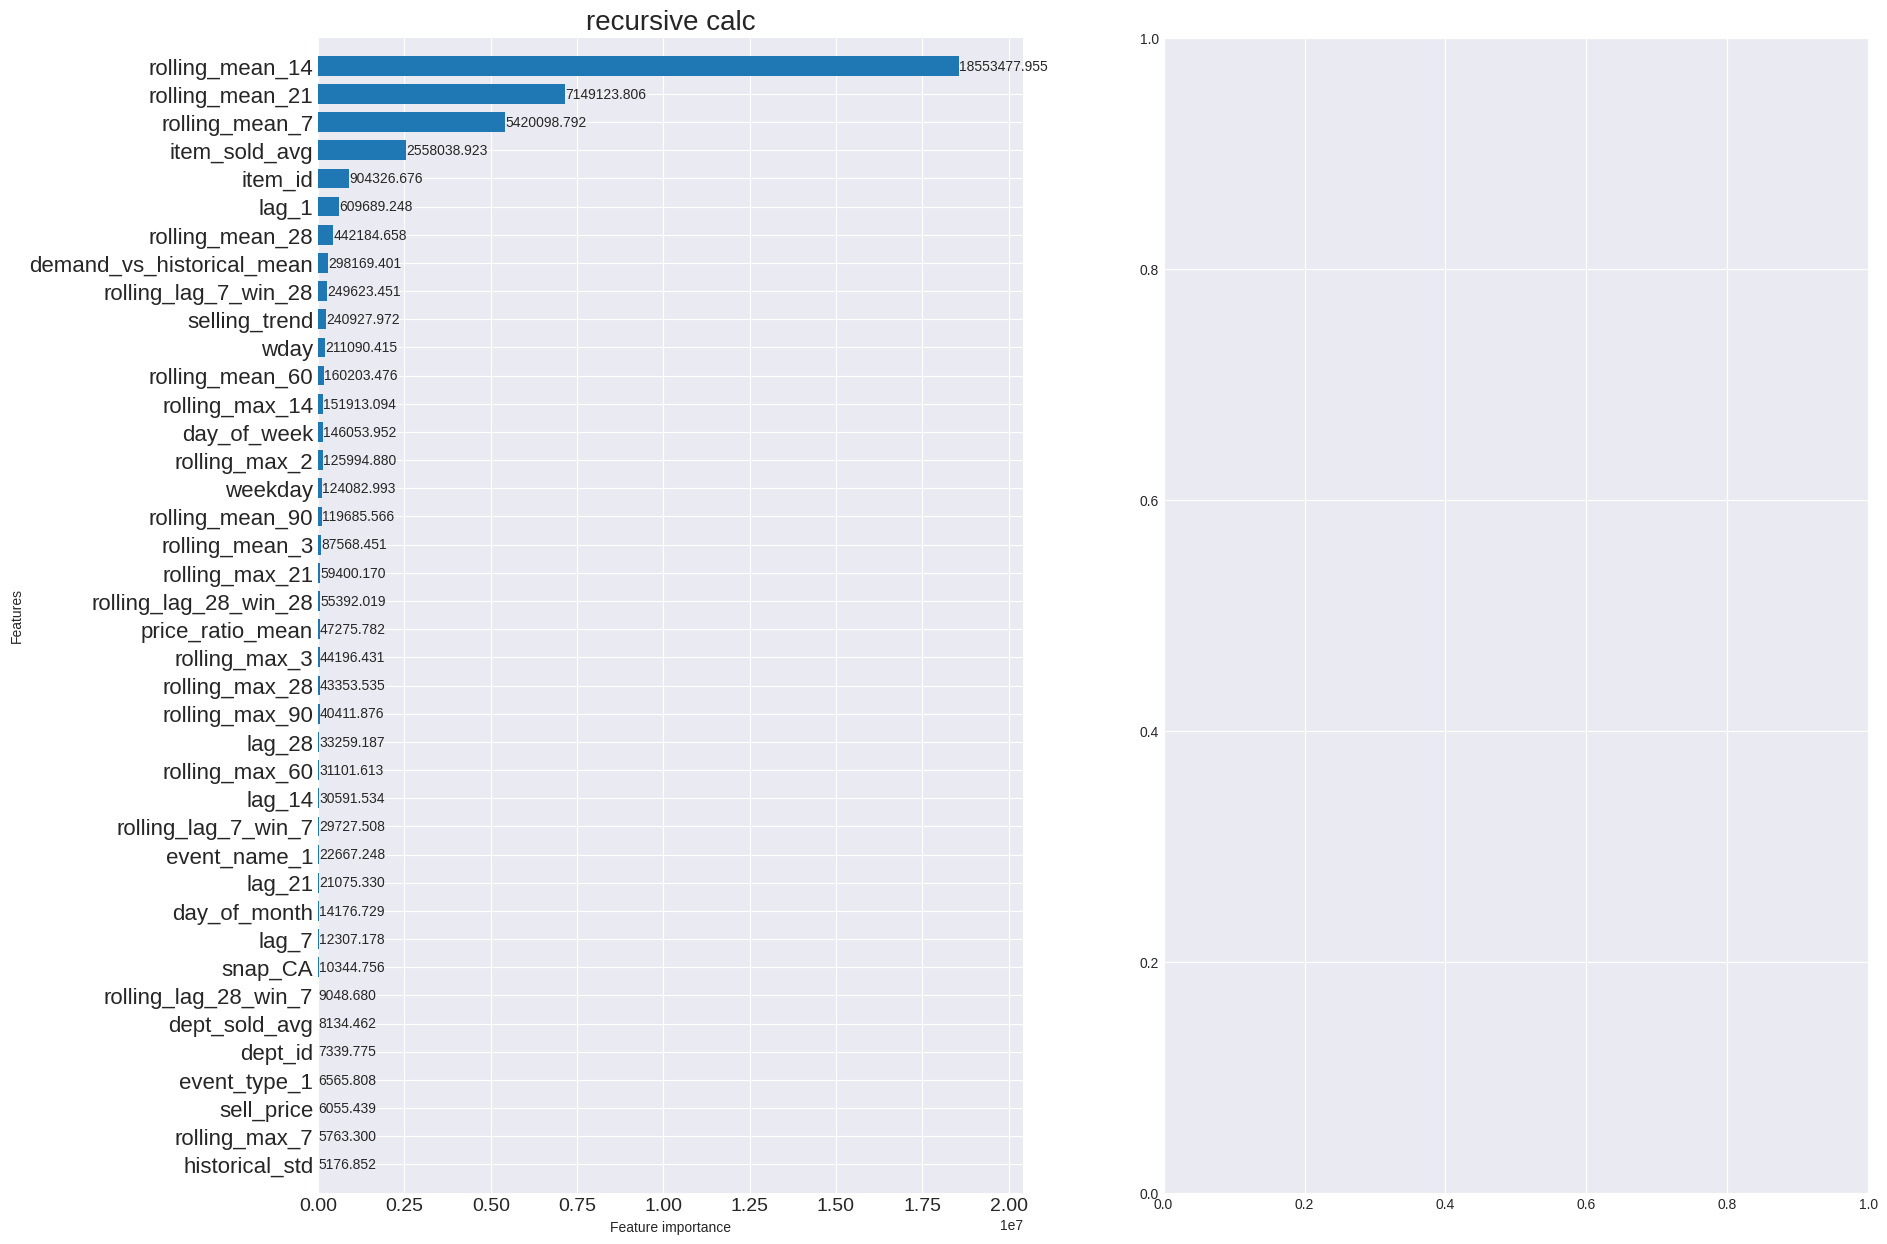

In [43]:
model_rec = model_sets['TREND_SET']
# model_direct = models_direct['BASE_SET']
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(20,15))
lgb.plot_importance(
    model_rec,
    max_num_features=40,  # Top 20 features
    importance_type='gain',  # Use 'gain' or 'split'
    height=0.7,
    ax=ax[0], title='recursive calc'
)
ax[0].tick_params(axis='y', labelsize=16)  # Feature names font size
ax[0].tick_params(axis='x', labelsize=14)  # X-axis values font size
ax[0].title.set_size(20)

# lgb.plot_importance(model_direct,max_num_features=40,importance_type='gain', height=0.7,ax=ax[1],title='direct leakage')
# ax[1].tick_params(axis='y', labelsize=16)  # Feature names font size
# ax[1].tick_params(axis='x', labelsize=14)  # X-axis values font size
# ax[1].title.set_size(20)

* It is worth noting that adding new features, definitely improves our wrmsse score, however, WAPE is not improving at all. This could be due to the fact that the lightGBM regressor, inherently minimizes squared error (which is why decrease in wrmsse, as it uses squared error)

* let's check how removing short term lags and rolling means, that add error in recursive forecasting would change the scores, we take the TREND_SET features for this and remove short term lags and rolling averages and keep the long ones

In [1]:
# # calculating wape at a higher heirarchical level

# actual_pred_df = test_rec.merge(predics['NEW_FEATS'],on=['item_id','date'],how='left')


# # 1. Create an absolute error column 
# actual_pred_df['abs_error'] = (
#     actual_pred_df['sales'] - actual_pred_df['sales_pred']
# ).abs()

# # 2. Calculate Department-level WAPE
# dept_wape = (
#     actual_pred_df.groupby('dept_id', observed=True)
#     .agg(sum_abs_error=('abs_error', 'sum'), sum_actual=('sales', 'sum'))
#     .reset_index()
# )

# dept_wape['wape'] = dept_wape['sum_abs_error'] / dept_wape['sum_actual']
# print(dept_wape[['dept_id', 'wape']])

# # 3. Calculate Category-level WAPE
# cat_wape = (
#     actual_pred_df.groupby('cat_id', observed=True)
#     .agg(sum_abs_error=('abs_error', 'sum'), sum_actual=('sales', 'sum'))
#     .reset_index()
# )

# cat_wape['wape'] = cat_wape['sum_abs_error'] / cat_wape['sum_actual']
# print(cat_wape[['cat_id', 'wape']])

* freeze the following feature set for further backtesting and stress testing evaluations

feat_set_ = BASE_SET + PRICE_SET + AGG_SET + TREND_SET + ['lag_21','lag_7','lag_28','lag_60','lag_90'] +['rolling_max_28', 'rolling_max_60', 'rolling_max_90', 'rolling_mean_7','rolling_mean_21','rolling_max_21', 'rolling_mean_28', 'rolling_mean_60','rolling_mean_90', 'rolling_lag_28_win_7', 'rolling_lag_28_win_28']


In [63]:
# for backtesting, choose 3 or 4 2 year windows from the original dataset

min_date = training_data['date'].min()
max_date = training_data['date'].max()

NUM_TRAINING_DAYS = 730 # 2 years

# for faster calculation, we only take 4 or 5 windows:

start_date = min_date + pd.Timedelta(days=56) # randomly added 

feats_to_drop = ['lag_7','lag_21']+['rolling_mean_7','rolling_max_21', 'rolling_mean_21','selling_trend','demand_vs_historical_mean']


# although sales trend also includes 'rolling_mean_7' we include it for now

def walk_forward_rolling(df, training_period = NUM_TRAINING_DAYS, features_selected=feat_set, total_windows=5,horizon=28):

    # choose 5 different start dates from whole dates
    available_dates = [ date for date in np.random.choice(df['date'].unique(),total_windows) if date<=(df['date'].max()-pd.Timedelta(days=730))]
    preds = {}
    models = {}
    for i,start_date in enumerate(available_dates):

     

        end_date = start_date + pd.Timedelta(days=training_period)

        print(f' window {i+1}: {start_date} to {end_date.date}')
        
        mask = df['date'].between(start_date, end_date)
        total_df = df.loc[mask].copy()

        # first calculate all features on total_df and remove recursive features from test after splitting
        # price feaetures : we already know the price for the future
        total_df = get_price_features(total_df)
        # avg sales : aggregated across, categories and department
        total_df = get_avg_sales(total_df)
        # lag features, remember: we have to delete the cols that need to be in recursive loop from test dataset
        #this col from test after this
        total_df = get_features.add_lags(total_df,lags=[1,7,21,28,60,90])
        # rolling features 
        total_df = get_features.add_rolling_max(total_df,source_col='lag_1',windows=[2,3,7,14,21,28,60,90])
        total_df = get_features.add_rolling_mean(total_df,source_col='lag_1',windows=[3,7,14,21,28,60,90])
        total_df = get_features.add_rolling_on_lag(total_df,lags=[7,28],windows=[7,28])
        # get trend features
        total_df = get_trend_features(total_df)

        
        ### choose the features
        total_df_feats = total_df[features_selected+['date','sales']]

      

        # split the data to train and test 
        cutoffdate = total_df['date'].max()-pd.Timedelta(days=horizon)

        train = total_df_feats[total_df_feats['date']<=cutoffdate].copy()
        test  = total_df_feats[total_df_feats['date']>cutoffdate].copy() 
        eval_df = test.copy()

        assert set(test.columns) == set(eval_df.columns)
  
        # break
    
        # remove the recursive features that  need to be calculated in loop
        test_new = test.drop(columns=feats_to_drop)

        # if 'historical_mean' in train.columns:
        #     print('in train yes')
        # elif 'historical_mean' in features_selected:
        #     print("yes in feature selected")
        # elif 'historical_mean' in test_new.columns:
        #     print("yes in test_new")
        # elif 'historical_mean' in total_df.columns:

        #     print('yes in total df')
        # else:
        #     print('no')
        # break        #### recursive loop ###### 

        active_models, cat_categories,params  = train_models(train,  eval_df ,feature_cols=features_selected)

        assert train['item_id'].nunique() == test_new['item_id'].nunique(),'Missing items'

        models[f'windows_{i}'] = active_models['point']

        if set(AGG_SET).issubset(features_selected):
            print(f"AGG SET: {AGG_SET} in feature_set")
            # copy the same agg calculated for tranining to test_new set, as recursively calculating this does not make sense
            agg_lookup = train[['item_id'] + AGG_SET].drop_duplicates('item_id')
            test_new = test_new.drop(columns=AGG_SET, errors='ignore').merge(agg_lookup, on='item_id', how='left')

        # predict recurssively
        pred_df,items_df = recursive_forecast_batch(models= active_models,history_df=train, future_static_df= test_new,
                                        feature_cols=features_selected,cat_categories=cat_categories)
        preds[f'window_{i+1}'] = pred_df
        # calculate the metrics
        score_wrmsse = wrmsse(train,test_new,pred_df)
        # mape = calculate_mape(test_new['sales'],pred_df['sales_pred'])
        wape = calculate_wape(test_new['sales'],pred_df['sales_pred'])

        bias_score = bias(test_new['sales'],pred_df['sales_pred'])

        print(f"WRMSSE: {score_wrmsse}, WAPE: {wape}, BIAS:{bias_score}")


        return preds


In [12]:
# choose the training data such that, it contain items that spans entire range
from src.utils import get_items_with_full_history 

df_full_hist = get_items_with_full_history(training_data)




total history:  1802
Total unique items: 3047
Items with full history: 1204


In [67]:

preds_windows = walk_forward_rolling(df_full_hist)


 window 1: 2011-06-25T00:00:00.000000000 to <bound method Timestamp.date of Timestamp('2013-06-24 00:00:00')>
using feature cols:  ['item_id', 'dept_id', 'cat_id', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'sell_price', 'day_of_week', 'day_of_month', 'week_of_year', 'price_ratio_mean', 'is_discounted', 'delta_price_rltv_dept', 'historical_std', 'item_sold_avg', 'dept_sold_avg', 'cat_sold_avg', 'selling_trend', 'demand_vs_historical_mean', 'lag_21', 'lag_7', 'lag_28', 'lag_60', 'lag_90', 'rolling_max_28', 'rolling_max_60', 'rolling_max_90', 'rolling_mean_7', 'rolling_mean_21', 'rolling_max_21', 'rolling_mean_28', 'rolling_mean_60', 'rolling_mean_90', 'rolling_lag_28_win_7', 'rolling_lag_28_win_28']
AGG SET: ['item_sold_avg', 'dept_sold_avg', 'cat_sold_avg'] in feature_set


KeyError: "['selling_trend', 'demand_vs_historical_mean'] not in index"